# Practical session n°7

Notions:
- Quantile regression
- Pinball Loss


Duration: 1 h 30

In this practical, we immerse ourselves again in the context where the training inputs ($x$) and targets ($y$) are images of the same spatial dimensions. However, we assume that the dependence of $y$ on $x$ is probabilistic in nature. In other words, there exist conditional laws $p(y | x)$, and these laws need to be characterized.

Here, we limit ourselves to conditional marginals, meaning the laws $p(y_{i,j} | x)$ where $y_{i,j}$ represents the value of the target $y$ at the pixel $(i,j)$. To characterize these laws, several approaches are possible. For instance, one can attempt to estimate their quantiles or moments. The following exercises illustrate a method for estimating quantiles.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models, transforms

In [2]:
# ! git clone https://github.com/nanopiero/ML_S5_etudiants
# import sys
# sys.path.append('ML_S5_etudiants/practicals/P7')
from utils_P7 import gen_proba, voir_batch2D, UNet

**Exercise 1**: on the PINBALL loss

As seen in the previous practical session n°4, using the Mean Absolute Error (MAE) led the model to provide the conditional median, which is a particular quantile. To estimate other quantiles, it is sufficient to modify the MAE.

This is what we are going to do on a simple problem where the link between the input and the target is defined by:
$$y_{i,j} \sim \mathcal{N}(\mu(x_{i,j}), \sigma(x_{i,j})) $$
where $\mu$ and $\sigma$ are a priori unknown.

The gen_proba function from the utile.py module will allow us to "explore" our dataset, or in other words, to sample the random pair $(x, y)$.

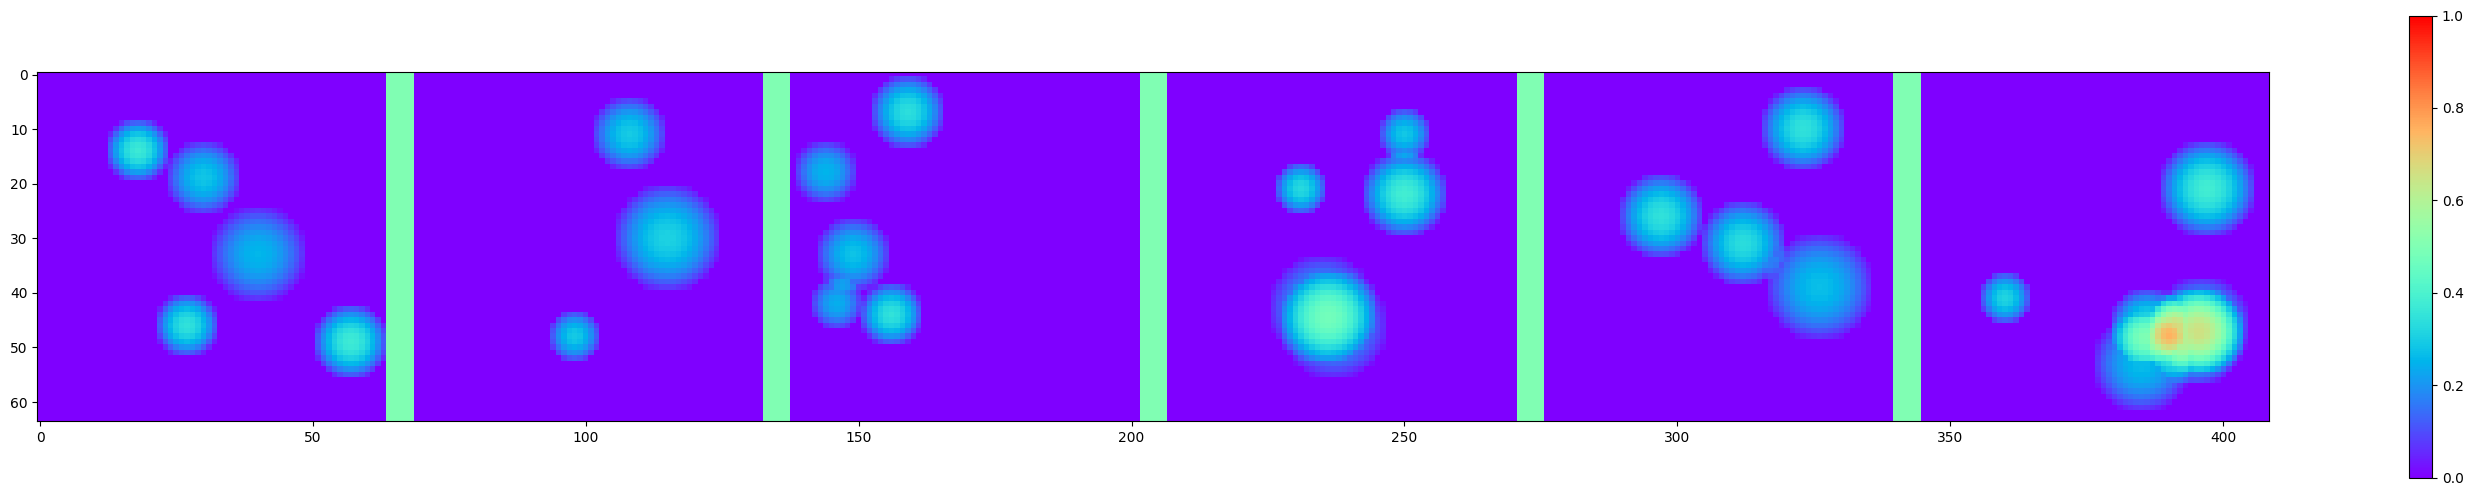

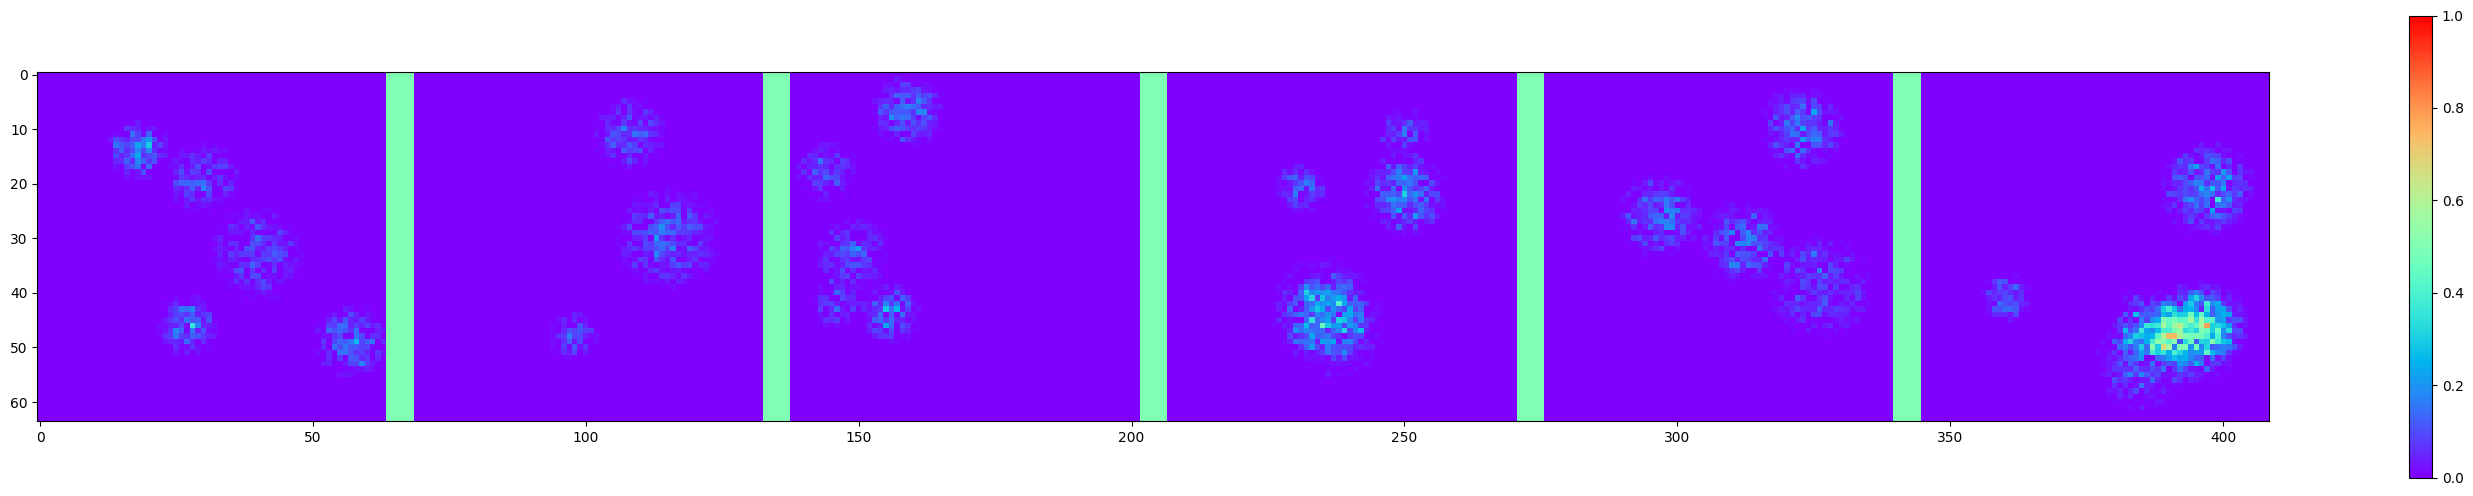

In [3]:
# sampling (x,y) :

input, target = gen_proba(6)
# Inputs
fig0 = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig0, k=0, min_scale=0,max_scale=1)

# Targets
fig1 = plt.figure(1, figsize=(36, 6))
voir_batch2D(target, 6, fig1, k=0, min_scale=0,max_scale=1)

Let's consider the cost function be defined at the pixel level by:
$$\mathcal{L}_t(y,z) =  \rho_t(z - y) $$  
where:
$$\rho_t(u) = t \times max(u,0) + (t-1) \times min(u,0) $$

**Q1** Plot the graph of $\rho_t$ for different values of $t$ in the range [0, 1] using *matplotlib.pyplot*.
How does $\mathcal{L}_t$ generalize the MAE?

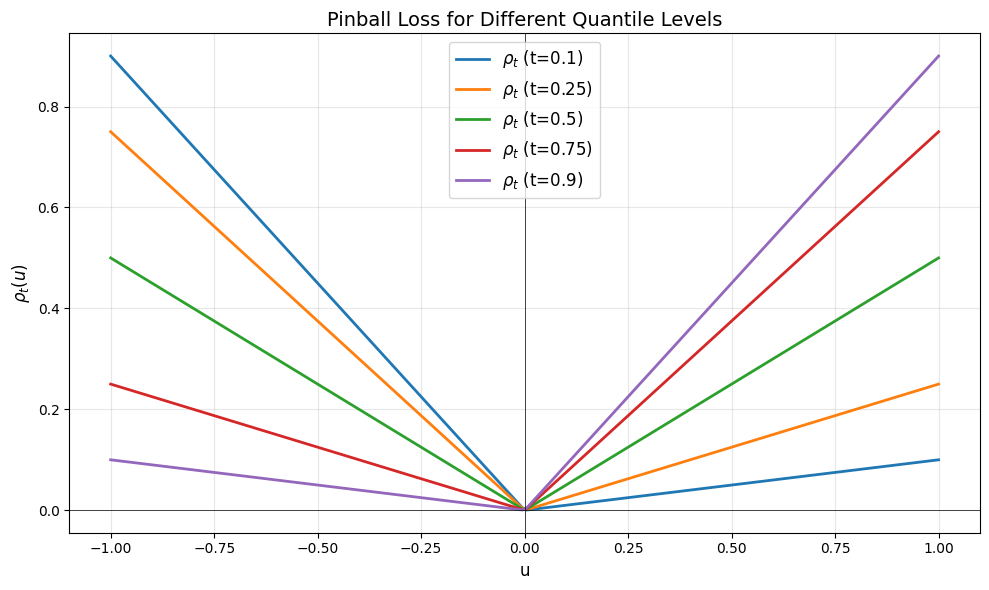

In [4]:
# Plot rho_t for different quantile levels
u = np.linspace(-1, 1, 200)
fig, ax = plt.subplots(figsize=(10, 6))

for t in [0.1, 0.25, 0.5, 0.75, 0.9]:
    rho_t = t * np.maximum(u, 0) + (t - 1) * np.minimum(u, 0)
    ax.plot(u, rho_t, label=f'$\\rho_{{t}}$ (t={t})', linewidth=2)

ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_xlabel('u', fontsize=12)
ax.set_ylabel('$\\rho_t(u)$', fontsize=12)
ax.set_title('Pinball Loss for Different Quantile Levels', fontsize=14)
plt.tight_layout()
plt.show()

# Commentary: The MAE (t=0.5) is a special case where rho_t is symmetric and estimates the median.
# For t<0.5: the loss penalizes overestimation more than underestimation
# For t>0.5: the loss penalizes underestimation more than overestimation
# This asymmetry allows us to estimate different quantiles of the conditional distribution.

**Q2** In the following cell, code a cost function adapted to the estimation of $t$-th quantiles (use *.clamp*( ))

In [5]:
def rho(u, t):
    """
    Compute the pinball loss (quantile loss).
    
    Args:
        u: residual (target - output) as a tensor
        t: quantile level in [0, 1]
    
    Returns:
        loss tensor
    """
    loss = t * torch.clamp(u, min=0) + (t - 1) * torch.clamp(u, max=0)
    return loss

**Q3** Train a U-Net to estimate the ninth decile.

In [6]:
# Initialize model, optimizer and criterion
fcn = UNet(1, 1).cuda()
optimizer = torch.optim.Adam(fcn.parameters(), lr=0.001)

def criterion(output, target):
  return rho(target - output, 0.9).mean()

In [7]:
nepochs = 50
nbatches = 100
batchsize = 64

train_losses = []

for epoch in range(nepochs):

    print("Epoch " + str(epoch))
    epoch_losses  = []
    for i in range(nbatches):

        # Sampling (X,Y)
        input,target = gen_proba(batchsize)

        input = input.cuda()
        target = target.cuda()

        # Forward
        optimizer.zero_grad()
        output = fcn(input)

        # Loss
        loss = criterion(output,target)

        # Gradients
        loss.backward()

        # Update weights
        optimizer.step()

        epoch_losses.append(loss.detach().cpu())

        del target, input, loss
        torch.cuda.empty_cache()

    epoch_loss = np.mean(epoch_losses)
    train_losses.append(epoch_loss)
    print('epoch loss : \n')
    print(epoch_loss)

Epoch 0
epoch loss : 

0.019652233
Epoch 1
epoch loss : 

0.0029349448
Epoch 2
epoch loss : 

0.0020747585
Epoch 3
epoch loss : 

0.0017525036
Epoch 4
epoch loss : 

0.001883947
Epoch 5
epoch loss : 

0.0017601573
Epoch 6
epoch loss : 

0.0015865836
Epoch 7
epoch loss : 

0.0015441478
Epoch 8
epoch loss : 

0.0016638844
Epoch 9
epoch loss : 

0.001554292
Epoch 10
epoch loss : 

0.0015670264
Epoch 11
epoch loss : 

0.0015924835
Epoch 12
epoch loss : 

0.0014355144
Epoch 13
epoch loss : 

0.0013409856
Epoch 14
epoch loss : 

0.0012833442
Epoch 15
epoch loss : 

0.0012936044
Epoch 16
epoch loss : 

0.0013024489
Epoch 17
epoch loss : 

0.0012869419
Epoch 18
epoch loss : 

0.0012720071
Epoch 19
epoch loss : 

0.0012593241
Epoch 20
epoch loss : 

0.001279901
Epoch 21
epoch loss : 

0.0012625561
Epoch 22
epoch loss : 

0.0013206755
Epoch 23
epoch loss : 

0.0012540601
Epoch 24
epoch loss : 

0.0012582067
Epoch 25
epoch loss : 

0.0012728983
Epoch 26
epoch loss : 

0.0012569516
Epoch 27
epoch 

**Q4** The ground truth is given by:
$$ \mu(x_{i,j}) = {x}_{i,j}^2 $$
and
$$ \sigma(x_{i,j}) = 0.2 \times x_{i,j} $$

Use [torch.distributions.normal.Normal](https://pytorch.org/docs/stable/distributions.html) to verify that the result corresponds well to the expected quantile.

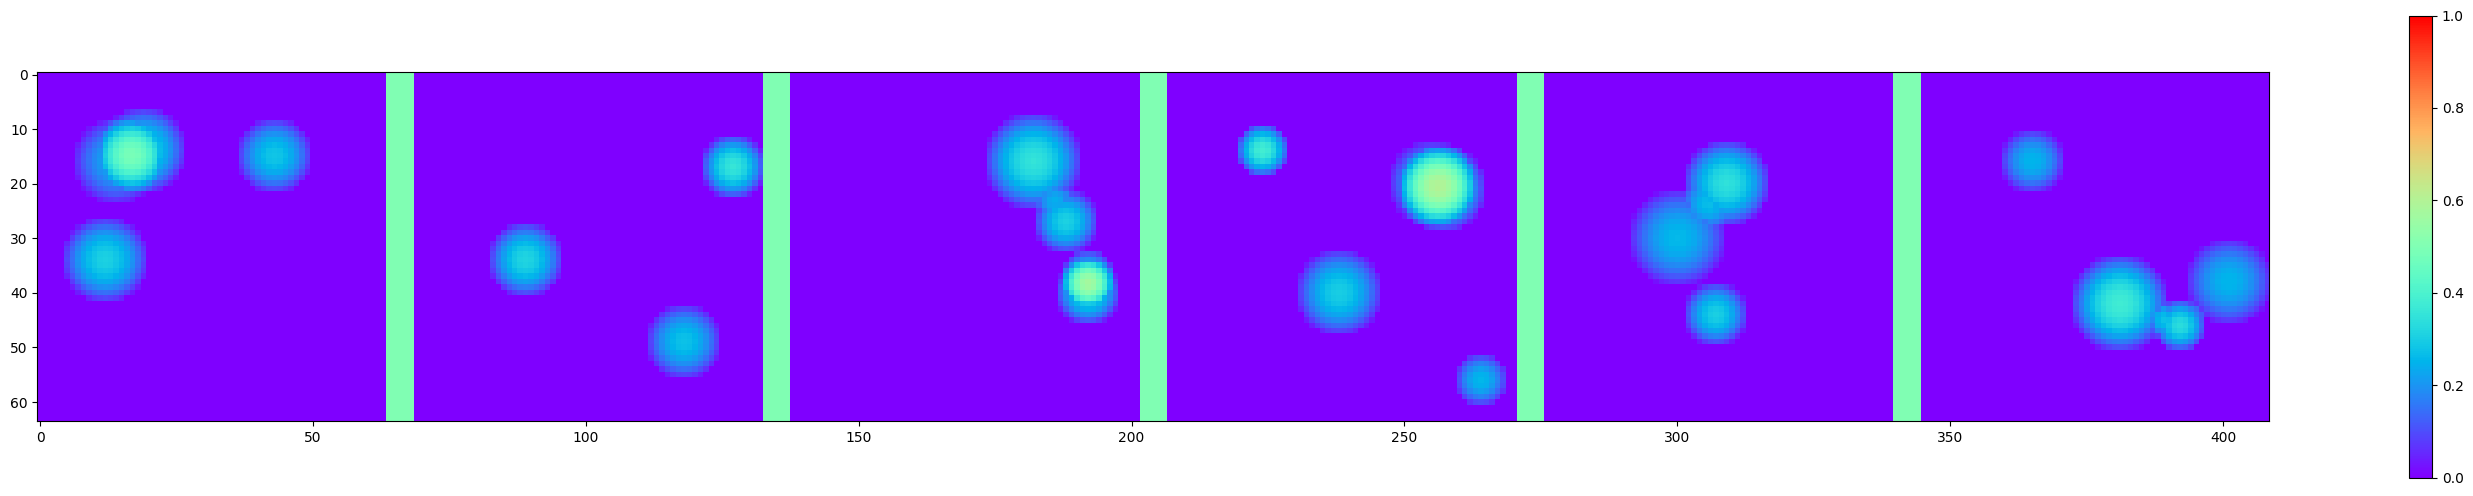

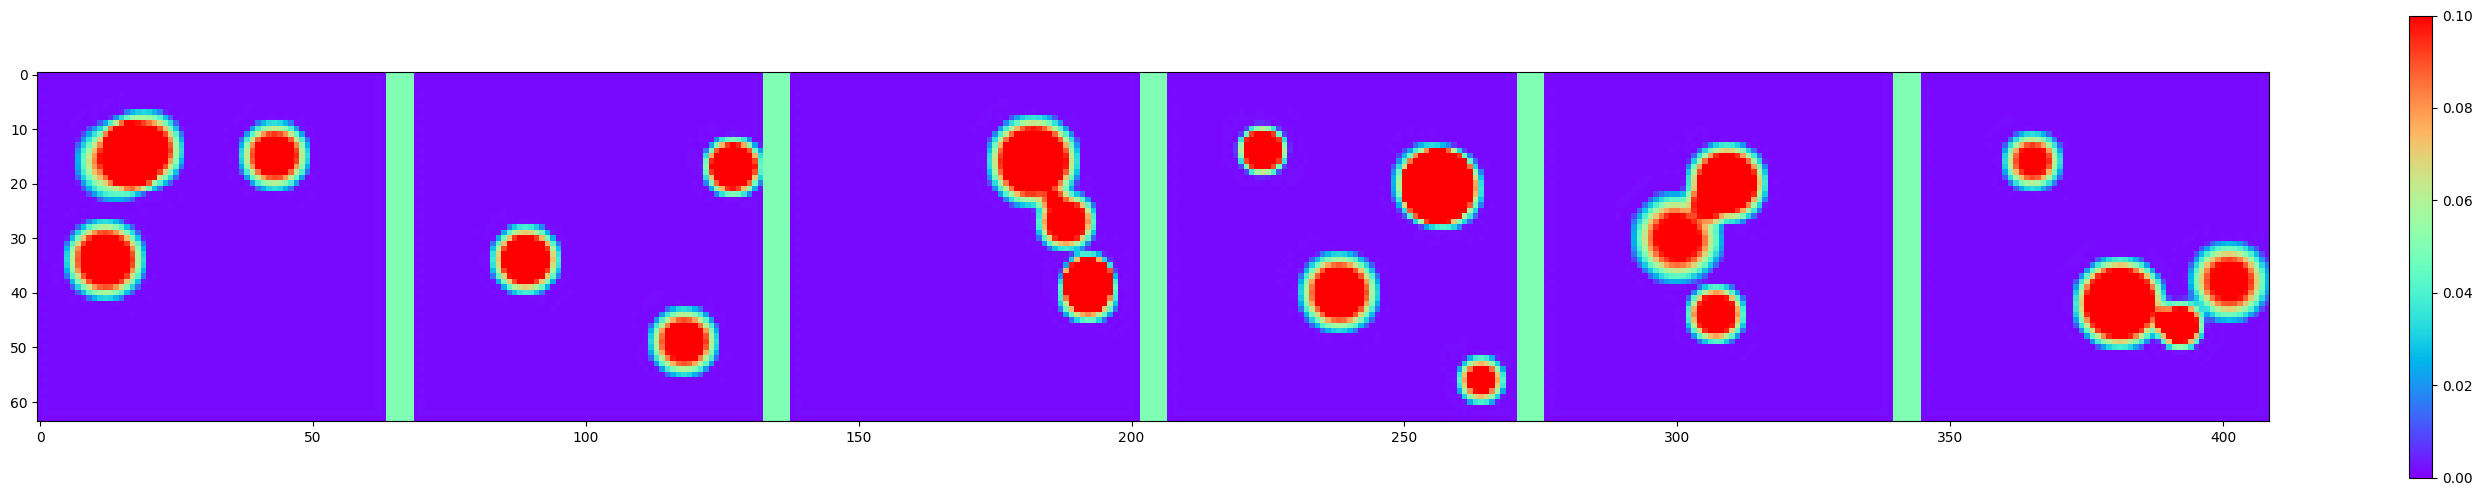

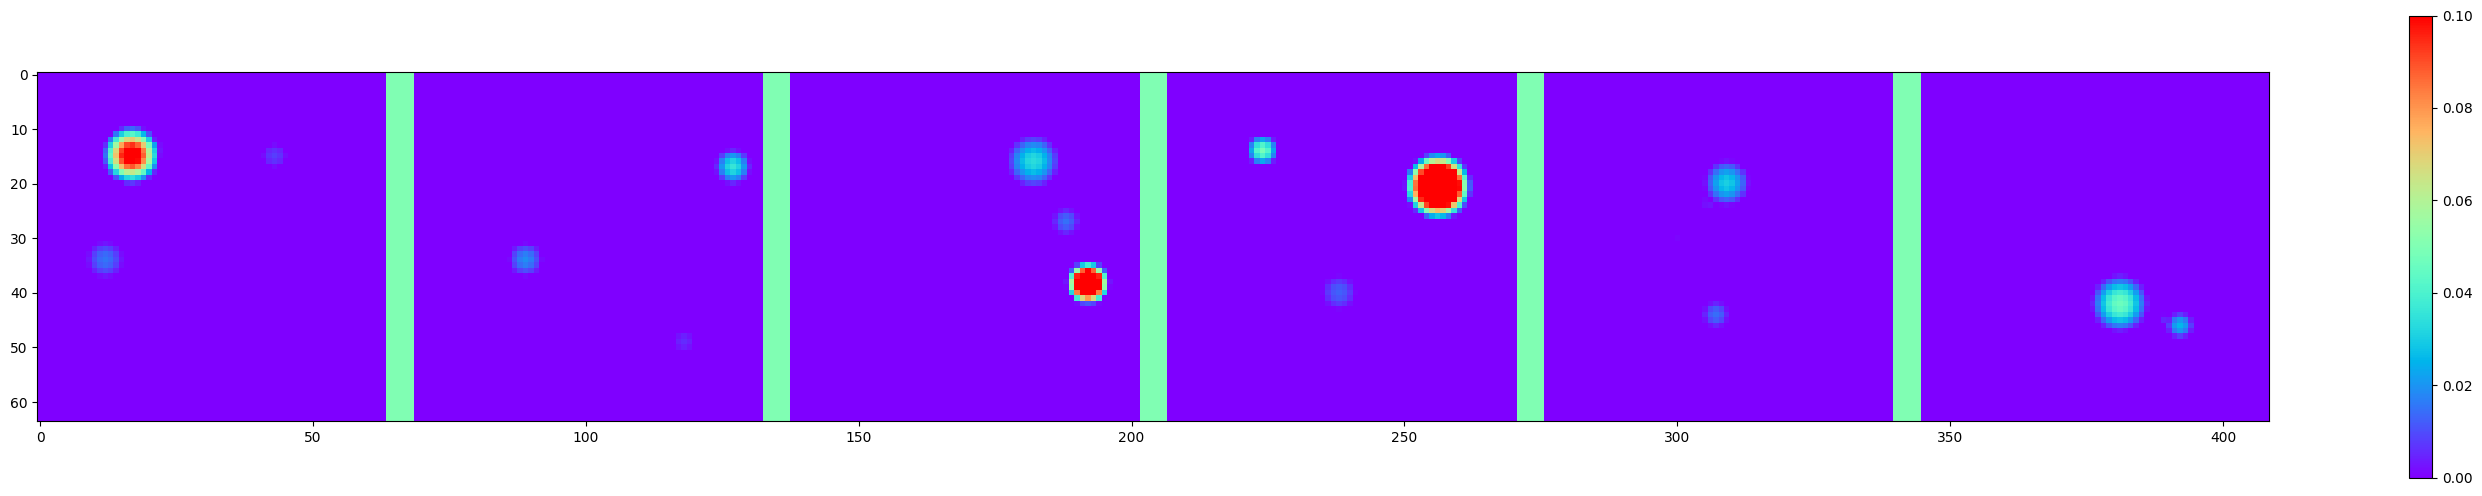

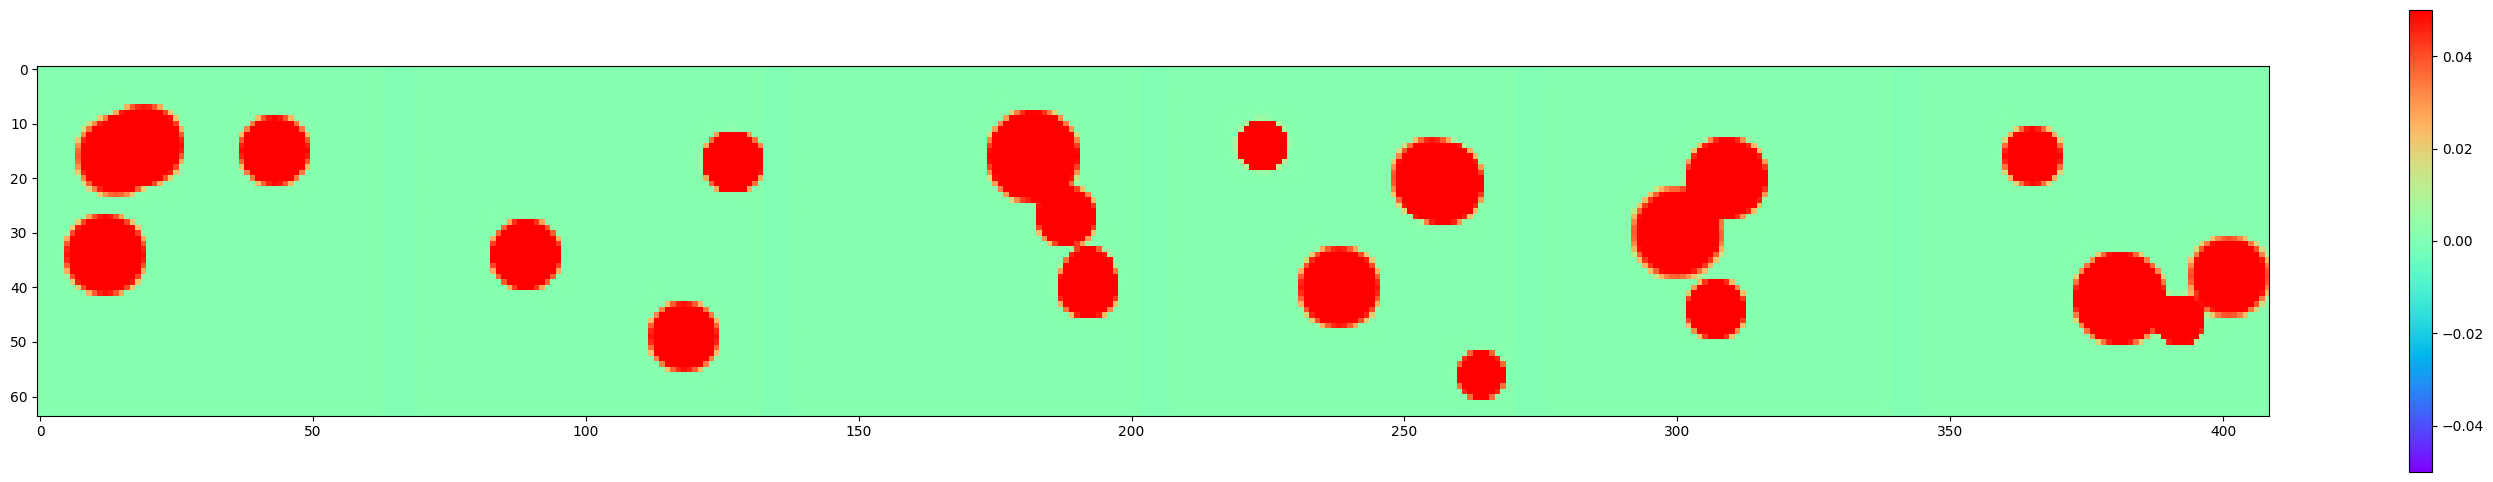

In [8]:
# viz:

fcn.eval()
input, target = gen_proba(6)
output = fcn(input.cuda())

fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig, k=0, min_scale=0,max_scale=1) #Entrées: première ligne
fig1 = plt.figure(1, figsize=(36, 6))
voir_batch2D(output.detach().cpu(), 6, fig1, k=0, min_scale=0,max_scale=0.1) #Sorties: deuxième ligne

# true quantile
m = torch.distributions.normal.Normal(input**2, 0.2*input+0.000001, validate_args=None)
quantiles = m.icdf(0*input + 0.1)
fig2 = plt.figure(2, figsize=(36, 6))
voir_batch2D(quantiles, 6, fig2, k=0, min_scale=0.,max_scale=0.1) #Premier décile (ground truth)
fig3 = plt.figure(3, figsize=(36, 6))
voir_batch2D(output.detach().cpu() - quantiles, 6, fig2, k=0, min_scale=-0.05,max_scale=0.05) #sorties - ground truth

**Exercise 2**: a trickier dependence

Let's now work with the following *gen_proba_2* function.

In [10]:
import sys
sys.path.append('../P5')
from utile import make_batch

def gen_proba_2(n):
  target1 = make_batch(n, rec = 0., noisy_rec= 0., disc = 0.0015)
  target2 = make_batch(n, rec = 0.001, noisy_rec= 0., disc = 0.)
  m = torch.normal(2, 2. + target2)
  input = target1 + target2
  target = m
  return  input, target

Here, the dependence of $y$ upon $x$ is not clearly visible in the input-target pairs:

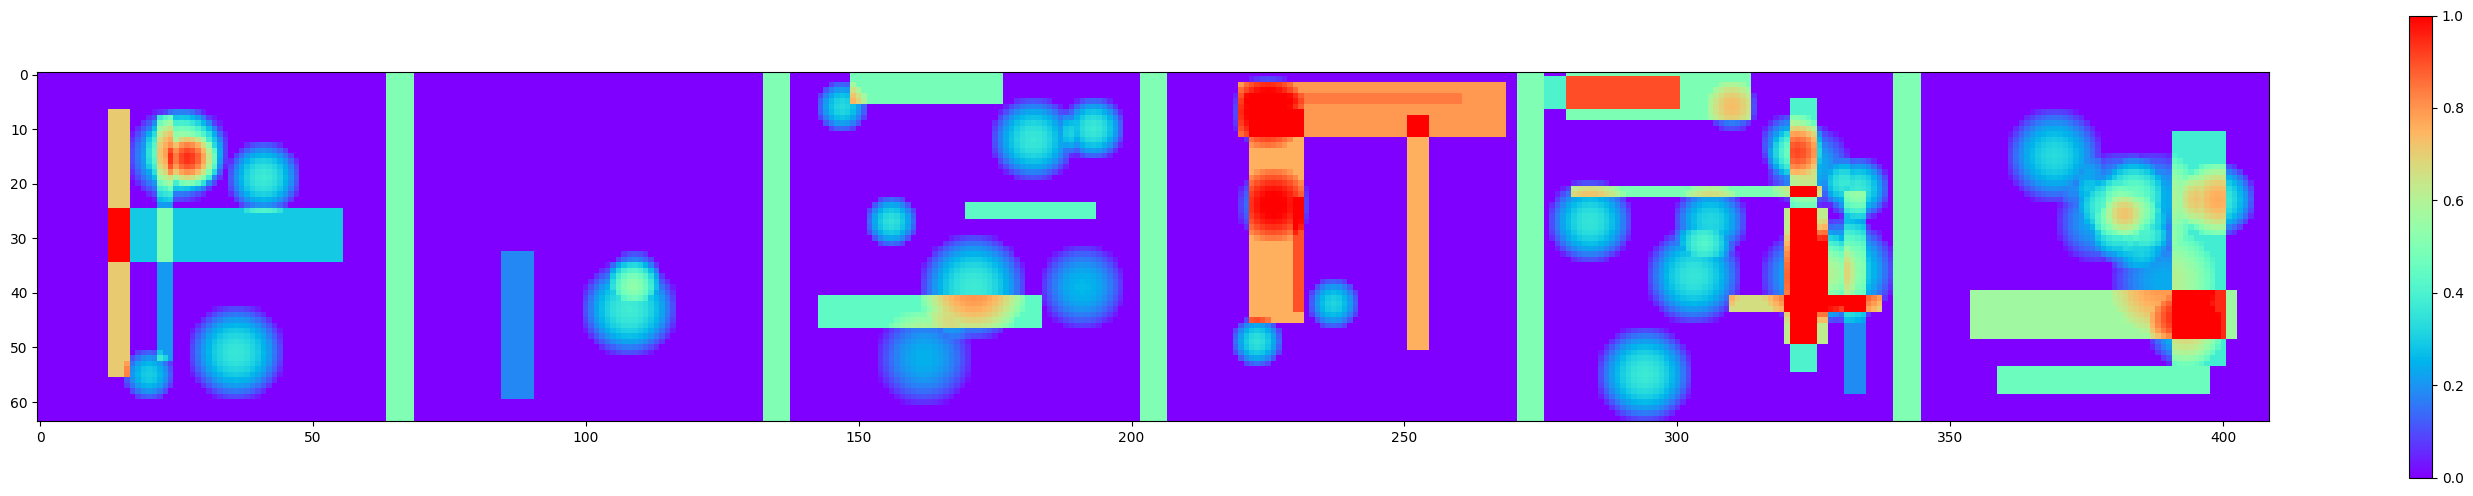

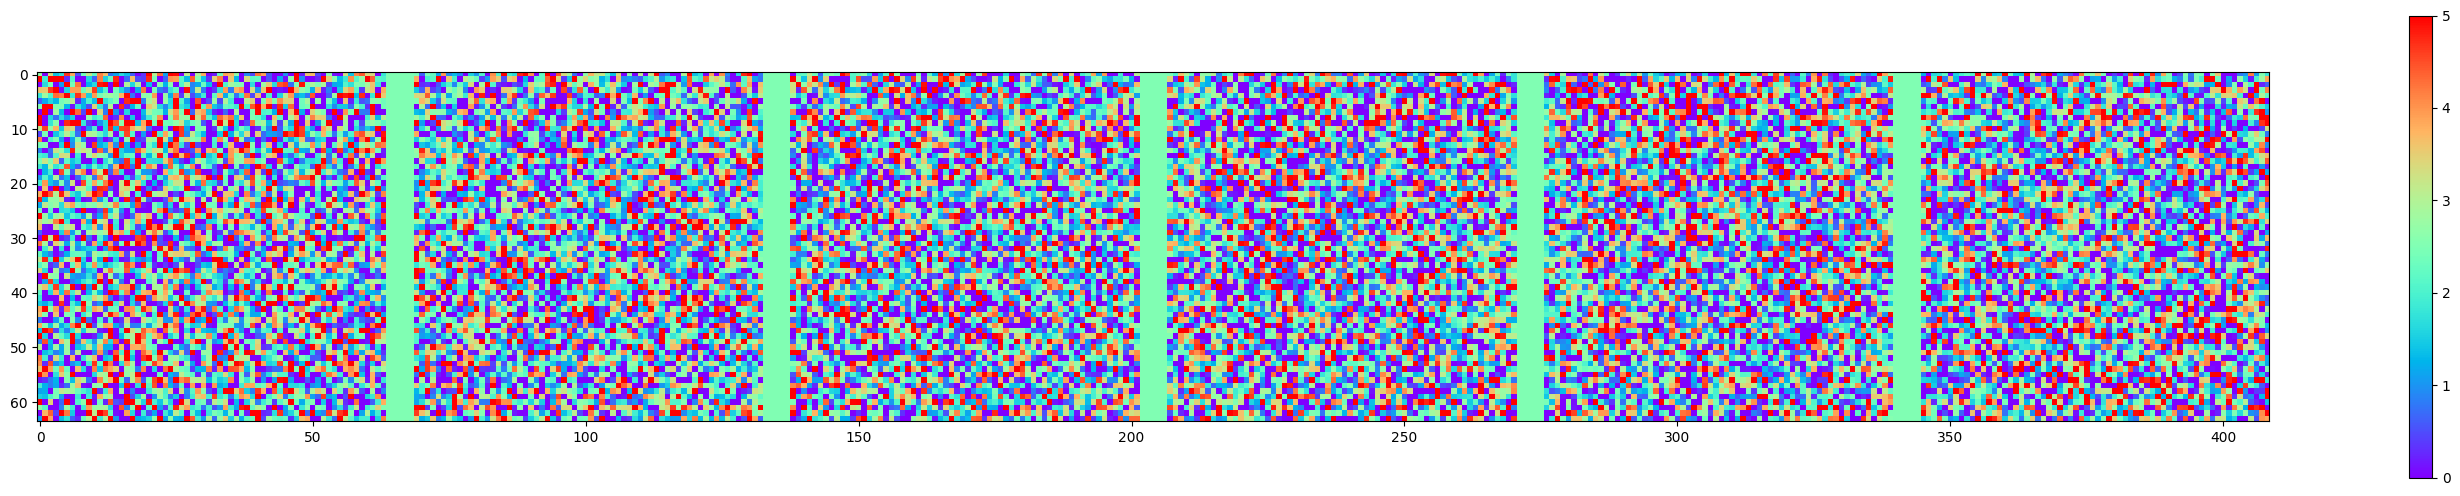

In [11]:
input, target = gen_proba_2(6)
# Inputs
fig0 = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig0, k=0, min_scale=0,max_scale=1)

# Targets
fig1 = plt.figure(1, figsize=(36, 6))
voir_batch2D(target, 6, fig1, k=0, min_scale=0,max_scale=5)

**Q1** Estimate the 0.1 quantiles of the marginal distributions and visualize the result.

In [12]:
# Initialize model for Exercise 2
fcn_exo2 = UNet(1, 1).cuda()
optimizer_exo2 = torch.optim.Adam(fcn_exo2.parameters(), lr=0.001)

def criterion_exo2(output, target):
  return rho(target - output, 0.1).mean()

# Training for estimating the 0.1 quantile (first decile)
nepochs = 50
nbatches = 100
batchsize = 64

train_losses_exo2 = []

for epoch in range(nepochs):
    print("Epoch " + str(epoch))
    epoch_losses = []
    for i in range(nbatches):
        # Sampling (X,Y)
        input, target = gen_proba_2(batchsize)
        
        input = input.cuda()
        target = target.cuda()
        
        # Forward
        optimizer_exo2.zero_grad()
        output = fcn_exo2(input)
        
        # Loss
        loss = criterion_exo2(output, target)
        
        # Gradients
        loss.backward()
        
        # Update weights
        optimizer_exo2.step()
        
        epoch_losses.append(loss.detach().cpu())
        
        del target, input, loss
        torch.cuda.empty_cache()
    
    epoch_loss = np.mean(epoch_losses)
    train_losses_exo2.append(epoch_loss)
    print('epoch loss : ' + str(epoch_loss))

Epoch 0
epoch loss : 0.36830658
Epoch 1
epoch loss : 0.36610743
Epoch 2
epoch loss : 0.3657938
Epoch 3
epoch loss : 0.36598206
Epoch 4
epoch loss : 0.3660149
Epoch 5
epoch loss : 0.36556184
Epoch 6
epoch loss : 0.3656627
Epoch 7
epoch loss : 0.3659352
Epoch 8
epoch loss : 0.3661123
Epoch 9
epoch loss : 0.36580792
Epoch 10
epoch loss : 0.36586314
Epoch 11
epoch loss : 0.3656831
Epoch 12
epoch loss : 0.3656113
Epoch 13
epoch loss : 0.36604786
Epoch 14
epoch loss : 0.3655659
Epoch 15
epoch loss : 0.3659796
Epoch 16
epoch loss : 0.3658682
Epoch 17
epoch loss : 0.36579114
Epoch 18
epoch loss : 0.36588004
Epoch 19
epoch loss : 0.36576566
Epoch 20
epoch loss : 0.3661252
Epoch 21
epoch loss : 0.36575893
Epoch 22
epoch loss : 0.36578426
Epoch 23
epoch loss : 0.36589155
Epoch 24
epoch loss : 0.3657955
Epoch 25
epoch loss : 0.36581832
Epoch 26
epoch loss : 0.365691
Epoch 27
epoch loss : 0.365684
Epoch 28
epoch loss : 0.36557674
Epoch 29
epoch loss : 0.36575544
Epoch 30
epoch loss : 0.36583114
Epo

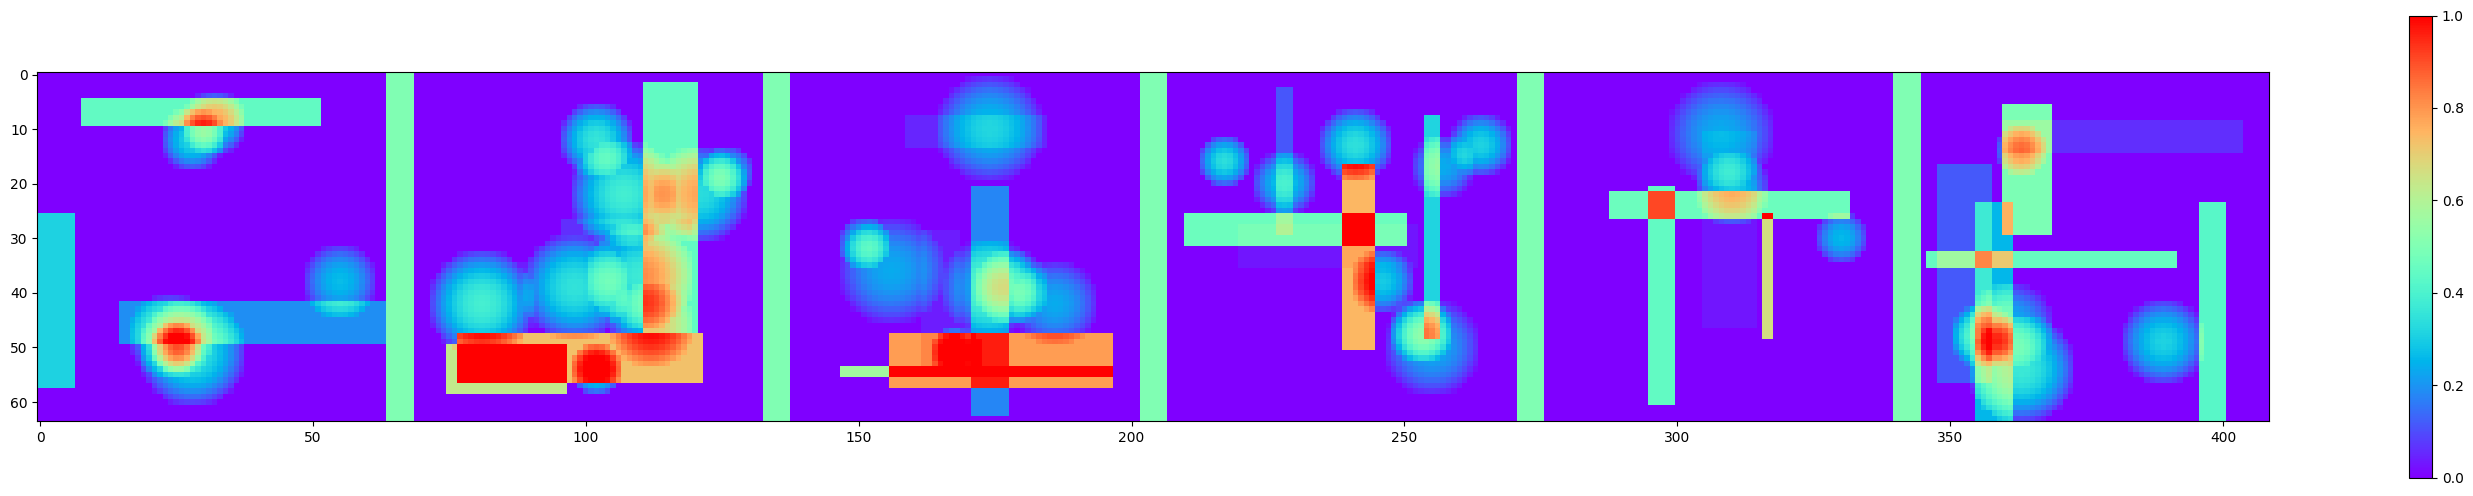

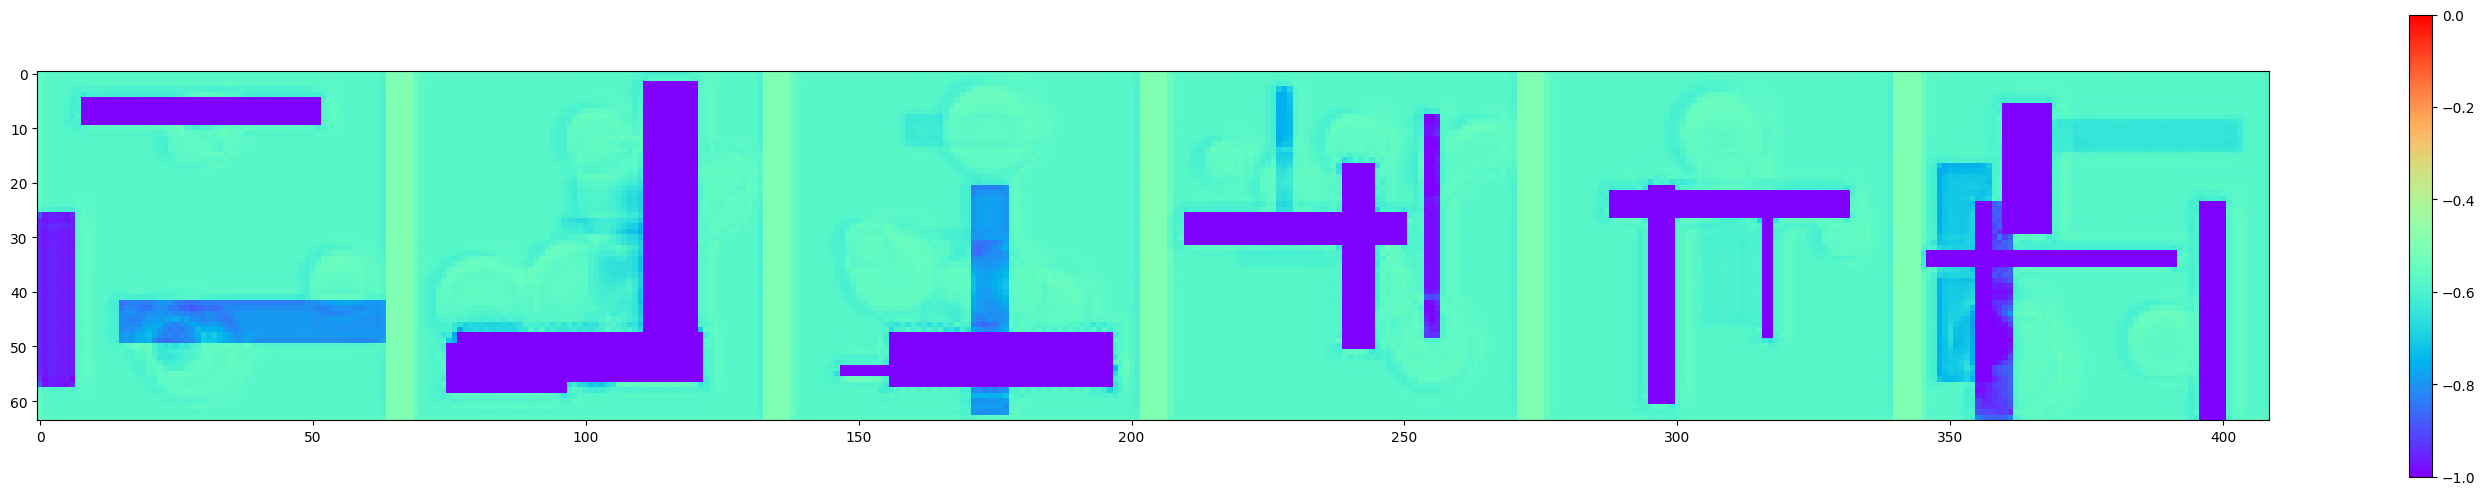

In [13]:
#visualisation:

fcn_exo2.eval()

input, target = gen_proba_2(6)

output = fcn_exo2(input.cuda())

fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig, k=0, min_scale=0,max_scale=1)
fig1 = plt.figure(1, figsize=(36, 6))
voir_batch2D(output.detach().cpu(), 6, fig1, k=0, min_scale=-1,max_scale=0)

**Q2** Do outputs depend on inputs? Is it a pixel-wise dependence as in exercise 1? (i.e., does the distribution of $y_{i,j}$ depend only on $x_{i,j}$)

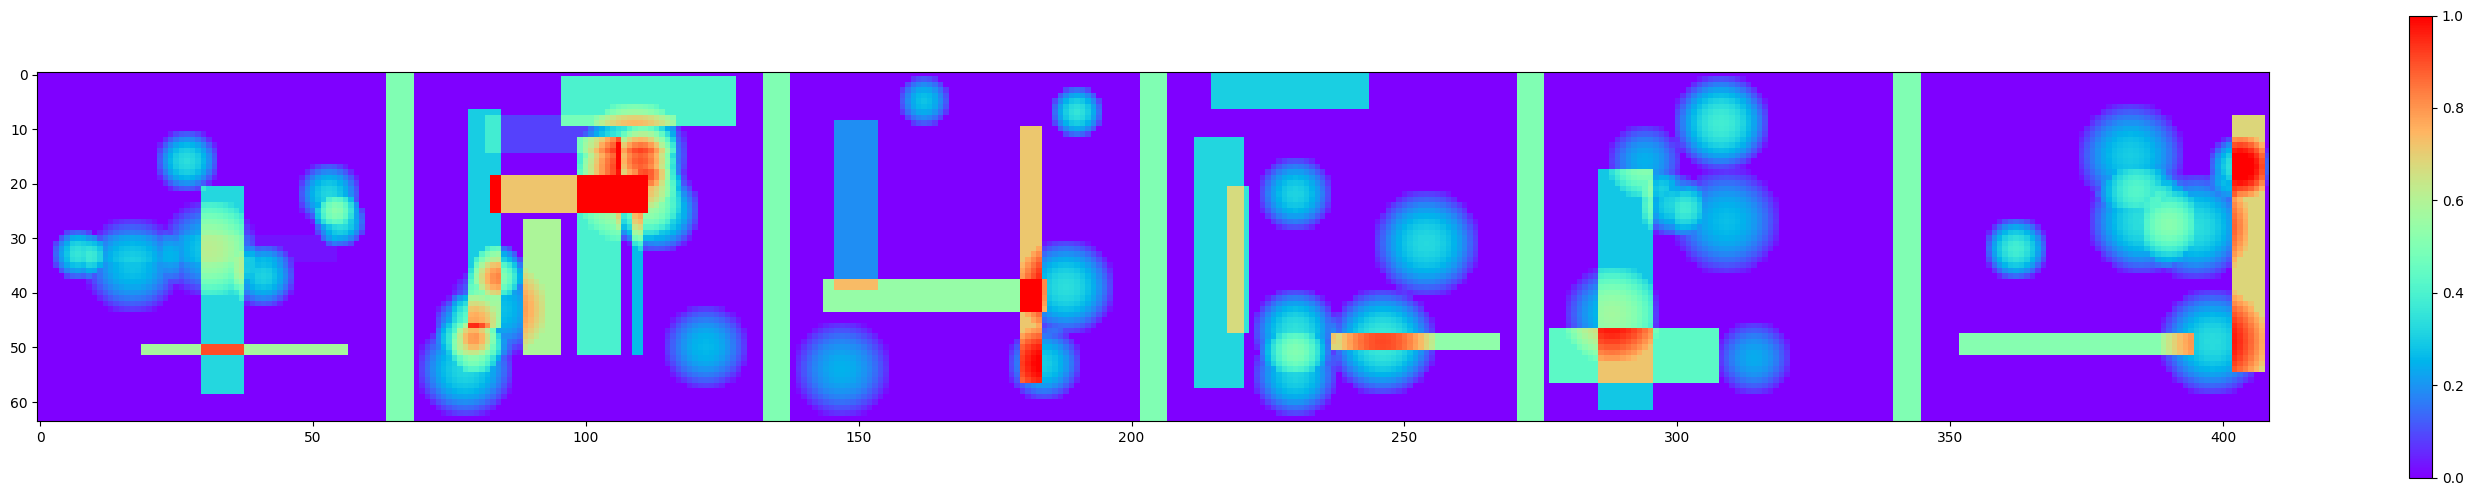

/tmp/ipykernel_1016790/3471410918.py:16: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig1 = plt.figure(1, figsize=(36, 6))


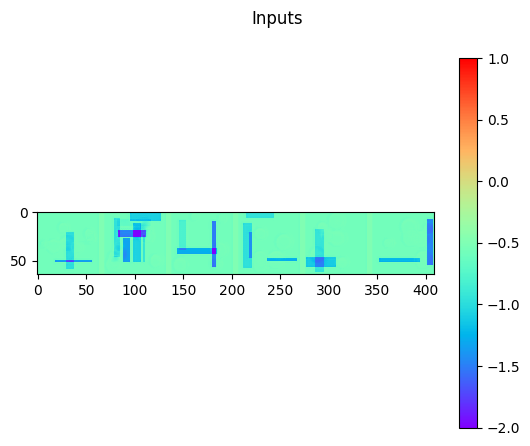

<Figure size 640x480 with 0 Axes>

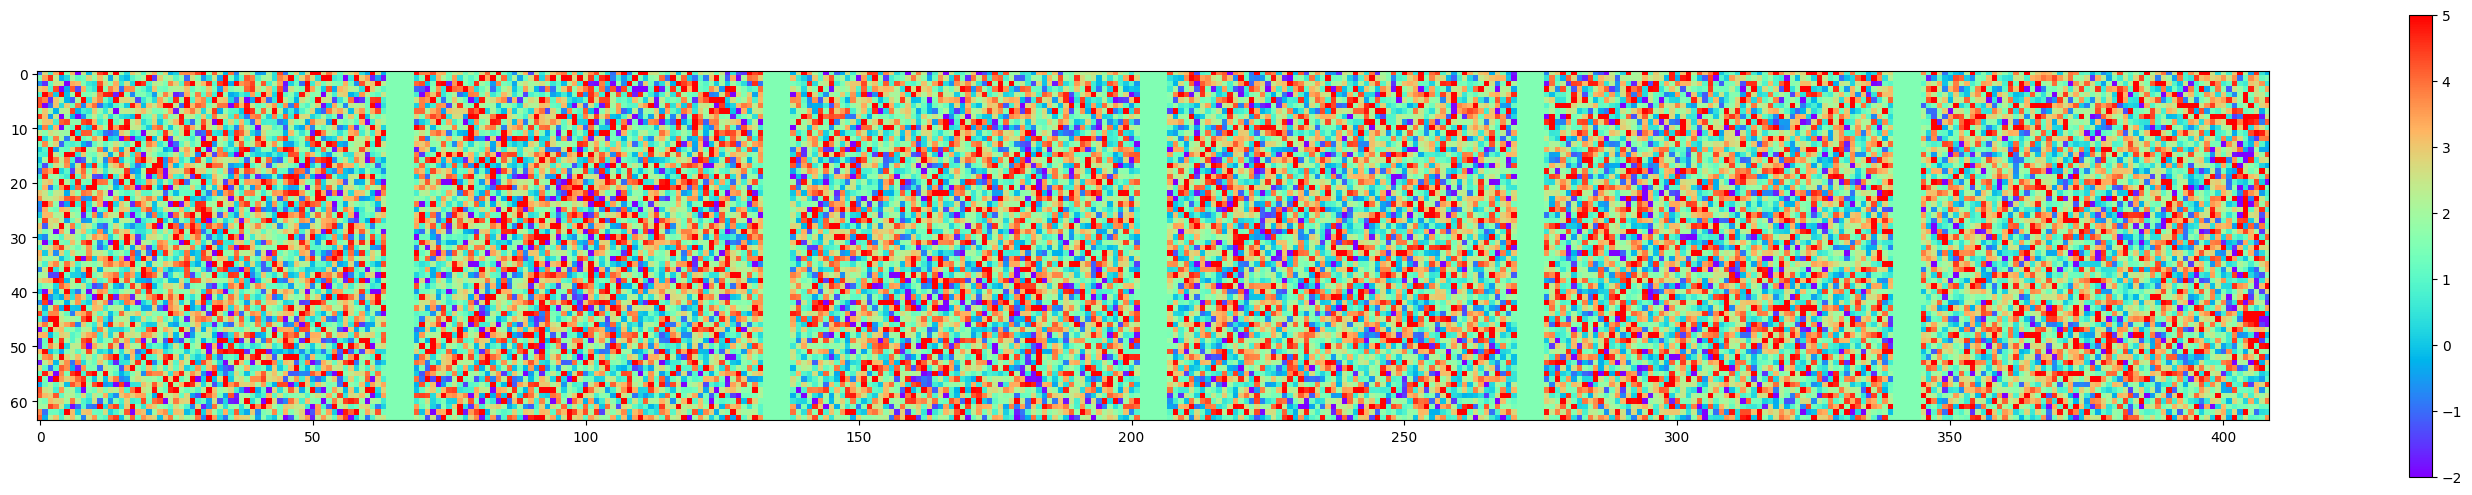

Text(0.5, 0.98, 'Target Values')

<Figure size 640x480 with 0 Axes>

In [14]:
# Analyze spatial dependencies in Exercise 2
fcn_exo2.eval()

# Generate a batch and visualize
input_sample, target_sample = gen_proba_2(6)

# Compute output
with torch.no_grad():
    output_sample = fcn_exo2(input_sample.cuda()).cpu()

# Visualization
fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input_sample, 6, fig, k=0, min_scale=0, max_scale=1)
plt.suptitle('Inputs')

fig1 = plt.figure(1, figsize=(36, 6))
voir_batch2D(output_sample, 6, fig1, k=0, min_scale=-2, max_scale=1)
plt.suptitle('Predicted 0.1 Quantiles')

fig2 = plt.figure(2, figsize=(36, 6))
voir_batch2D(target_sample, 6, fig2, k=0, min_scale=-2, max_scale=5)
plt.suptitle('Target Values')

# Analysis:
# Q2 Analysis: The outputs DO depend on inputs, but NOT in a purely pixel-wise manner.
# In Exercise 1, the distribution p(y_ij | x_ij) depended only on the pixel value x_ij.
# In Exercise 2, the variance of y depends on a global feature target2 (which is spatially smooth),
# not just on individual pixels. Therefore, this is a SPATIAL dependency where the output at 
# each pixel depends on a larger spatial neighborhood, not just the current pixel value.



**Exercise 3**:

One can attempt to estimate $n$ quantiles simultaneously. To achieve this, the simplest way is to:

* change the number of output channels of the U-Net—e.g., 99 channels if you are estimating the $n = 100$ quantiles of orders 1%, 2%, ... 99%.
* define the overall cost function by summing individual cost functions for each of the channels.
The goal of this exercise is to code a matrix version of this overall cost function and illustrate the convergence of the learning process.


**Q1** Let $t$ be a vector of size $n-1$, and $M$ be a 4th-order tensor. Code the function: $$dot(t, M) = M^{\prime}$$ where: $$M^{\prime}_{b,i,j} = \underset{0<c<n}{\sum} t_c \times M_{b,c,i,j}$$.

This function will allow to apply $\rho_{t_c}$ (see **Exercise 1**) to each channel $c$ of the output $M$ (where $b$ represents the batch index and $i,j$ represent spatial dimensions).

In [15]:
def dot(t, M):
	return (M * t.view((1,t.shape[0],1,1)) ).sum(dim=1)

**Q2** Complete the class *QuantileLoss*:

In [16]:
class QuantileLoss(torch.nn.Module):

    def __init__(self , n):
        super(QuantileLoss, self).__init__()
        self.n = n   # n= 100 -> centiles
        self.t = torch.arange(1/n,1,1/n).cuda()  # quantile orders

    def forward(self, output, target):
        bs, _, nx, ny = target.shape
        d = target.view(bs, 1, nx, ny) - output
        loss_by_pix = dot(self.t , d.clamp(min =0)) \
                      + dot( self.t - 1 , d.clamp(max =0))
        loss = torch.mean(loss_by_pix)

        return loss

**Q3** Start the training with *gen_proba* and $n=100$, then evaluate the estimation.

Epoch 0
epoch loss : 1.1596817
Epoch 1
epoch loss : 0.30527613
Epoch 2
epoch loss : 0.28249797
Epoch 3
epoch loss : 0.27051198
Epoch 4
epoch loss : 0.2572976
Epoch 5
epoch loss : 0.24190646
Epoch 6
epoch loss : 0.25647765
Epoch 7
epoch loss : 0.23491894
Epoch 8
epoch loss : 0.22784017
Epoch 9
epoch loss : 0.22974887
Epoch 10
epoch loss : 0.21221386
Epoch 11
epoch loss : 0.21288878
Epoch 12
epoch loss : 0.21143562
Epoch 13
epoch loss : 0.20605187
Epoch 14
epoch loss : 0.20295614
Epoch 15
epoch loss : 0.20321289
Epoch 16
epoch loss : 0.19571577
Epoch 17
epoch loss : 0.20173389
Epoch 18
epoch loss : 0.19724996
Epoch 19
epoch loss : 0.20054416
Epoch 20
epoch loss : 0.19344576
Epoch 21
epoch loss : 0.19265348
Epoch 22
epoch loss : 0.19329563
Epoch 23
epoch loss : 0.19318327
Epoch 24
epoch loss : 0.19292094
Epoch 25
epoch loss : 0.19428514
Epoch 26
epoch loss : 0.19497815
Epoch 27
epoch loss : 0.18831617
Epoch 28
epoch loss : 0.19077574
Epoch 29
epoch loss : 0.19714278
Epoch 30
epoch loss : 

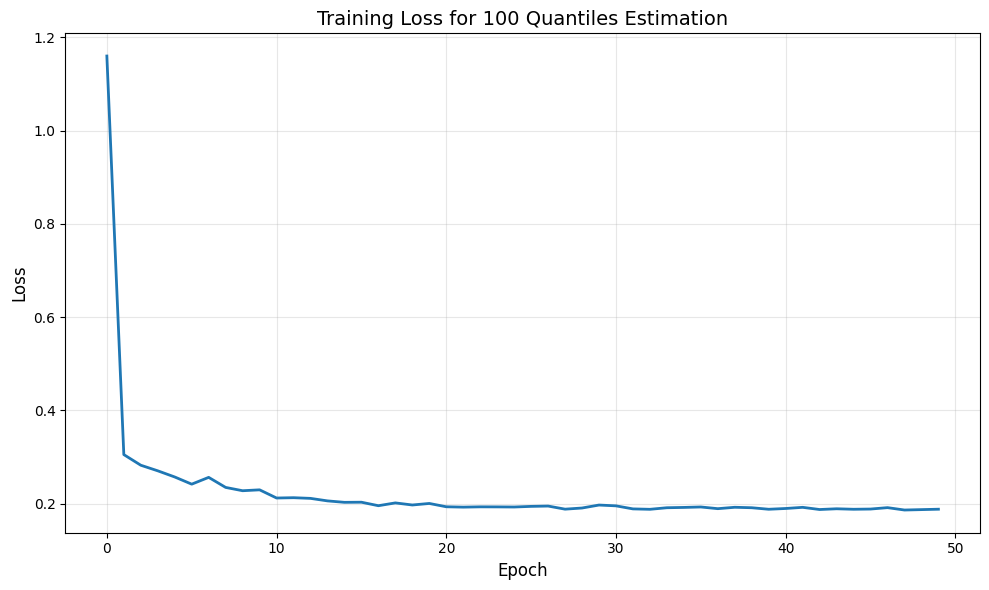

In [17]:
# Train U-Net to estimate 100 quantiles simultaneously
n_quantiles = 100

# Initialize model with 99 output channels (for quantiles 1%, 2%, ..., 99%)
fcn_exo3 = UNet(1, n_quantiles - 1).cuda()
optimizer_exo3 = torch.optim.Adam(fcn_exo3.parameters(), lr=0.001)

# Initialize the QuantileLoss
criterion_exo3 = QuantileLoss(n_quantiles)

# Training
nepochs = 50
nbatches = 100
batchsize = 64

train_losses_exo3 = []

for epoch in range(nepochs):
    print("Epoch " + str(epoch))
    epoch_losses = []
    for i in range(nbatches):
        # Sampling (X,Y)
        input, target = gen_proba(batchsize)
        
        input = input.cuda()
        target = target.cuda()
        
        # Forward
        optimizer_exo3.zero_grad()
        output = fcn_exo3(input)
        
        # Loss (already averaged inside QuantileLoss)
        loss = criterion_exo3(output, target)
        
        # Gradients
        loss.backward()
        
        # Update weights
        optimizer_exo3.step()
        
        epoch_losses.append(loss.detach().cpu())
        
        del target, input, loss
        torch.cuda.empty_cache()
    
    epoch_loss = np.mean(epoch_losses)
    train_losses_exo3.append(epoch_loss)
    print('epoch loss : ' + str(epoch_loss))

# Plot training convergence
plt.figure(figsize=(10, 6))
plt.plot(train_losses_exo3, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss for 100 Quantiles Estimation', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()